In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from scipy import stats

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_excel('Book1.xlsx', sheet_name='Master_combined')

print("✅ Data loaded successfully!")
print(f"📊 Total rows: {len(df)}")

✅ Data loaded successfully!
📊 Total rows: 661


In [ ]:
print("=" * 60)
print("📊 DEFINING FEATURES, TARGETS, AND VALIDATION SPLIT")
print("=" * 60)

# Define features (climate variables)
feature_columns = ['temperature', 'rainfall', 'SPI']

# Define targets
target_columns = ['EC', 'nitrate', 'chloride', 'sulfate', 'pH']

print(f"📌 Features: {feature_columns}")
print(f"📌 Targets: {target_columns}")

# Temporal Holdout Split
train_years = [2015, 2016, 2017, 2018, 2019, 2020, 2021]
test_years = [2022, 2023, 2024]

train_df = df[df['Year'].isin(train_years)].copy()
test_df = df[df['Year'].isin(test_years)].copy()

print(f"\n📌 Training years: {train_years}")
print(f"   Training rows: {len(train_df)}")
print(f"📌 Testing years: {test_years}")
print(f"   Testing rows: {len(test_df)}")

📊 DEFINING FEATURES, TARGETS, AND VALIDATION SPLIT
📌 Features: ['temperature', 'rainfall', 'SPI']
📌 Targets: ['EC', 'nitrate', 'chloride', 'sulfate', 'pH']

📌 Training years: [2015, 2016, 2017, 2018, 2019, 2020, 2021]
   Training rows: 484
📌 Testing years: [2022, 2023, 2024]
   Testing rows: 177


In [ ]:
print("=" * 60)
print("📊 TRAINING MODELS AND CALCULATING RESIDUALS")
print("=" * 60)

# Prepare features
X_train = train_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Store models and results
models = {}
residuals = {}

for target in target_columns:
    print(f"\n📌 Training for {target.upper()}...")

    # Get training data
    y_train = train_df[target].copy()
    train_mask = ~y_train.isna()
    X_train_clean = X_train_scaled[train_mask]
    y_train_clean = y_train[train_mask]

    if len(X_train_clean) == 0:
        continue

    # Train Random Forest
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_clean, y_train_clean)
    models[target] = rf

    # Get predictions on training data
    y_train_pred = rf.predict(X_train_clean)

    # Calculate residuals (errors)
    residuals[target] = y_train_clean - y_train_pred

    print(f"   ✅ Model trained")
    print(f"   📊 Residuals: min={residuals[target].min():.2f}, max={residuals[target].max():.2f}")

print("\n✅ All models trained and residuals calculated!")

📊 TRAINING MODELS AND CALCULATING RESIDUALS

📌 Training for EC...
   ✅ Model trained
   📊 Residuals: min=-967.60, max=1645.40

📌 Training for NITRATE...
   ✅ Model trained
   📊 Residuals: min=-16.69, max=103.67

📌 Training for CHLORIDE...
   ✅ Model trained
   📊 Residuals: min=-172.60, max=367.39

📌 Training for SULFATE...
   ✅ Model trained
   📊 Residuals: min=-491.92, max=731.28

📌 Training for PH...
   ✅ Model trained
   📊 Residuals: min=-3.33, max=1.38

✅ All models trained and residuals calculated!


In [ ]:
print("=" * 60)
print("📊 CREATING PREDICTION INTERVALS (CONFORMAL PREDICTION)")
print("=" * 60)

def get_prediction_intervals(models, residuals, X_test_scaled, target, confidence=0.95):
    """
    Create prediction intervals using conformal prediction
    """
    # Get model predictions
    rf = models[target]
    y_pred = rf.predict(X_test_scaled)

    # Calculate residual quantile
    residual_abs = np.abs(residuals[target])
    quantile = np.percentile(residual_abs, confidence * 100)

    # Create intervals
    lower_bound = y_pred - quantile
    upper_bound = y_pred + quantile

    return y_pred, lower_bound, upper_bound, quantile

# Store results
uncertainty_results = []

for target in target_columns:
    if target not in models:
        continue

    # Get test data
    y_test = test_df[target].copy()
    test_mask = ~y_test.isna()
    X_test_clean = X_test_scaled[test_mask]
    y_test_clean = y_test[test_mask]

    if len(X_test_clean) == 0:
        continue

    # Get prediction intervals
    y_pred, lower, upper, quantile = get_prediction_intervals(
        models, residuals, X_test_clean, target
    )

    # Calculate metrics
    mae = mean_absolute_error(y_test_clean, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred))
    r2 = r2_score(y_test_clean, y_pred)

    # Calculate coverage (how many actual values fall in the interval)
    coverage = np.mean((y_test_clean >= lower) & (y_test_clean <= upper)) * 100

    # Calculate average interval width
    avg_width = np.mean(upper - lower)

    uncertainty_results.append({
        'Parameter': target.upper(),
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Prediction_Interval': f"{quantile:.2f}",
        'Coverage_%': coverage,
        'Avg_Width': avg_width,
        'n_samples': len(y_test_clean)
    })

    print(f"\n📌 {target.upper()}:")
    print(f"   MAE: {mae:.2f}")
    print(f"   RMSE: {rmse:.2f}")
    print(f"   R²: {r2:.3f}")
    print(f"   Avg Interval Width: {avg_width:.2f}")
    print(f"   Coverage: {coverage:.1f}% (expected: {95:.0f}%)")

# Save results
uncertainty_df = pd.DataFrame(uncertainty_results)
uncertainty_df.to_excel('Uncertainty_Results.xlsx', index=False)
print("\n✅ Uncertainty results saved to: Uncertainty_Results.xlsx")

📊 CREATING PREDICTION INTERVALS (CONFORMAL PREDICTION)

📌 EC:
   MAE: 313.04
   RMSE: 418.15
   R²: 0.066
   Avg Interval Width: 1410.23
   Coverage: 92.6% (expected: 95%)

📌 NITRATE:
   MAE: 9.48
   RMSE: 16.71
   R²: 0.000
   Avg Interval Width: 66.71
   Coverage: 94.8% (expected: 95%)

📌 CHLORIDE:
   MAE: 35.62
   RMSE: 70.14
   R²: 0.093
   Avg Interval Width: 205.19
   Coverage: 92.3% (expected: 95%)

📌 SULFATE:
   MAE: 110.76
   RMSE: 184.60
   R²: 0.054
   Avg Interval Width: 510.83
   Coverage: 86.5% (expected: 95%)

📌 PH:
   MAE: 0.48
   RMSE: 0.76
   R²: -0.017
   Avg Interval Width: 1.87
   Coverage: 90.4% (expected: 95%)

✅ Uncertainty results saved to: Uncertainty_Results.xlsx


In [ ]:
print("=" * 60)
print("📊 OUT-OF-DISTRIBUTION (OOD) DETECTION")
print("=" * 60)

def detect_ood(new_data, training_data, threshold=2.0):
    """
    Detect if new data is outside training distribution using z-scores
    """
    # Calculate mean and std of training data
    train_mean = training_data.mean(axis=0)
    train_std = training_data.std(axis=0)

    # Calculate z-scores for new data
    z_scores = np.abs((new_data - train_mean) / train_std)

    # Any feature with z-score > threshold is OOD
    is_ood = np.any(z_scores > threshold, axis=1)

    return is_ood, z_scores

# Test OOD detection
print("\n📌 Testing OOD detection on test data...")

# Use training data for reference
training_features = X_train_scaled

# Test each test point
test_ood_results = []
for i in range(len(X_test_scaled)):
    point = X_test_scaled[i].reshape(1, -1)
    is_ood, z_scores = detect_ood(point, training_features)
    test_ood_results.append({
        'Index': i,
        'Is_OOD': is_ood[0],
        'Max_Z_Score': z_scores.max()
    })

ood_df = pd.DataFrame(test_ood_results)
ood_count = ood_df['Is_OOD'].sum()
print(f"\n📌 OOD test results:")
print(f"   Total test points: {len(ood_df)}")
print(f"   OOD points detected: {ood_count} ({ood_count/len(ood_df)*100:.1f}%)")

# Save
ood_df.to_excel('OOD_Detection.xlsx', index=False)
print("\n✅ OOD detection results saved to: OOD_Detection.xlsx")

# Show example OOD points
if ood_count > 0:
    print("\n📌 Example OOD points:")
    print(ood_df[ood_df['Is_OOD']].head())

📊 OUT-OF-DISTRIBUTION (OOD) DETECTION

📌 Testing OOD detection on test data...

📌 OOD test results:
   Total test points: 177
   OOD points detected: 112 (63.3%)

✅ OOD detection results saved to: OOD_Detection.xlsx

📌 Example OOD points:
   Index  Is_OOD  Max_Z_Score
0      0    True     2.192456
1      1    True     2.192456
2      2    True     2.192456
3      3    True     2.192456
4      4    True     2.192456


📊 VISUALIZING UNCERTAINTY


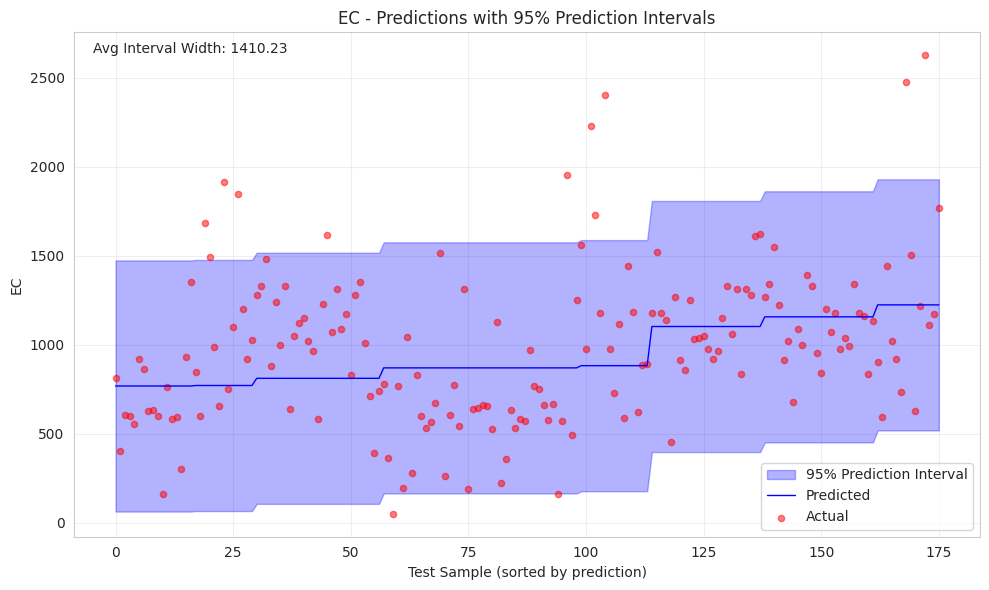

✅ Saved: Uncertainty_EC.png


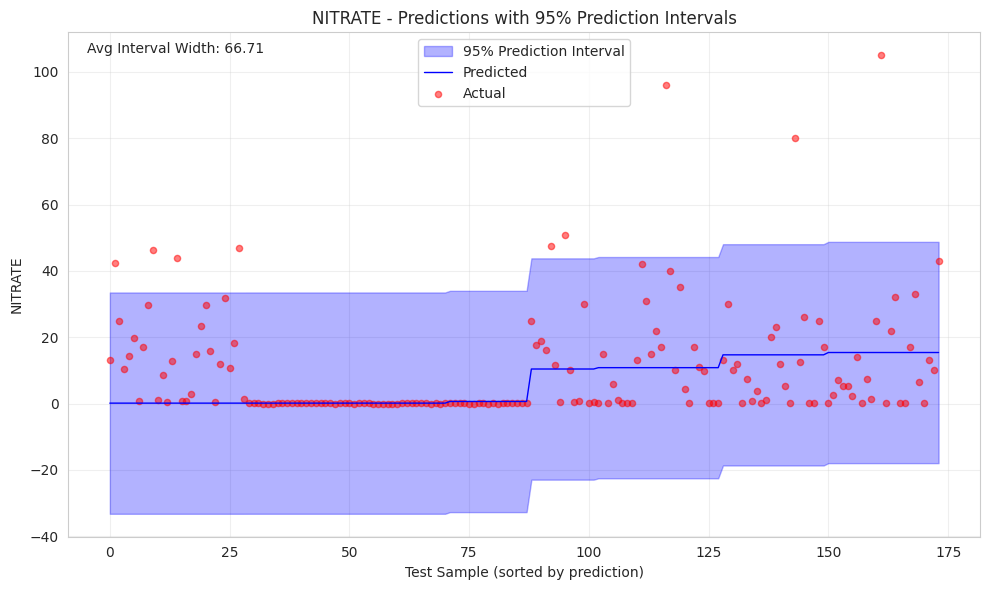

✅ Saved: Uncertainty_nitrate.png


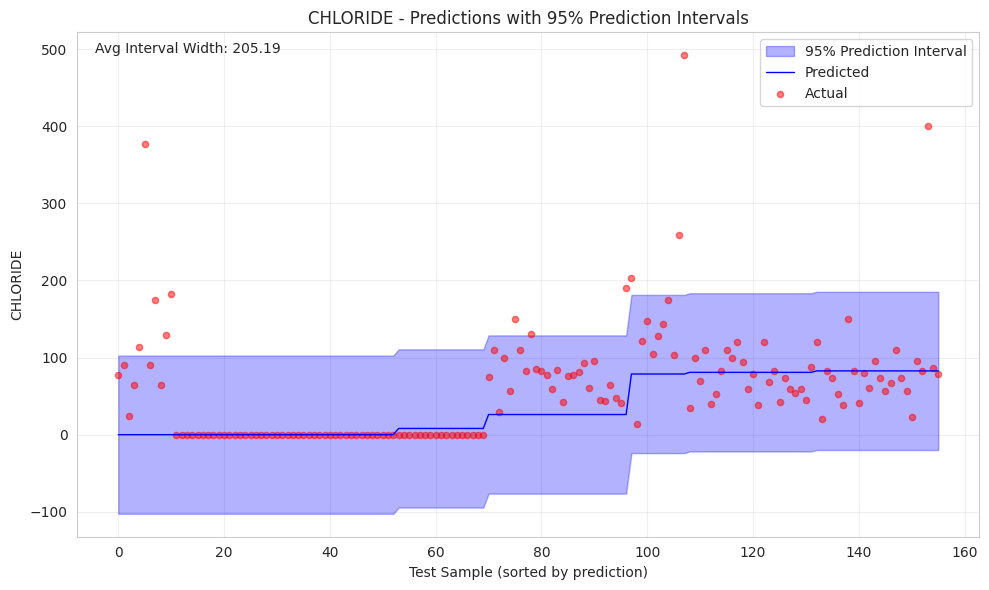

✅ Saved: Uncertainty_chloride.png


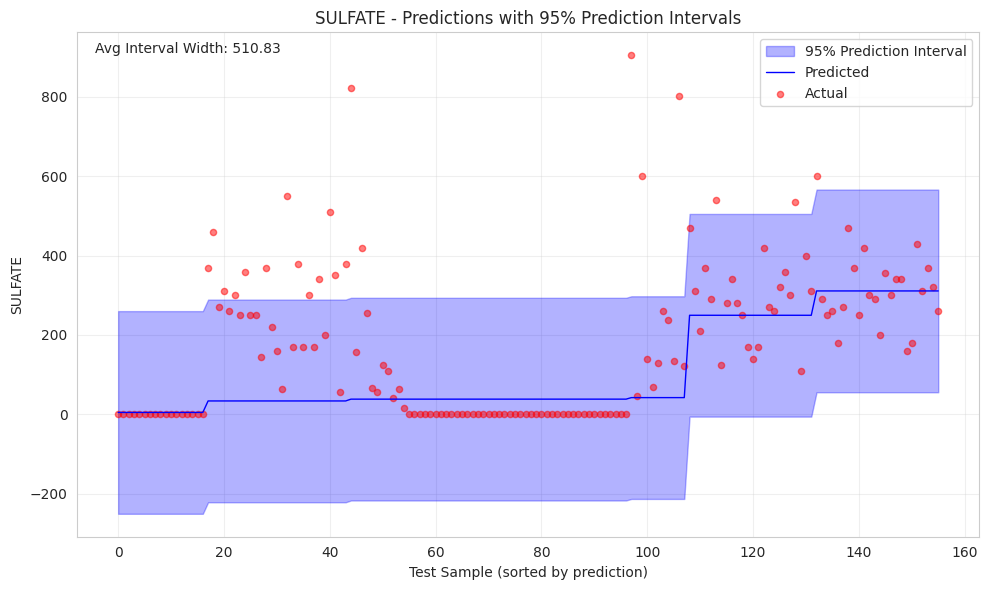

✅ Saved: Uncertainty_sulfate.png


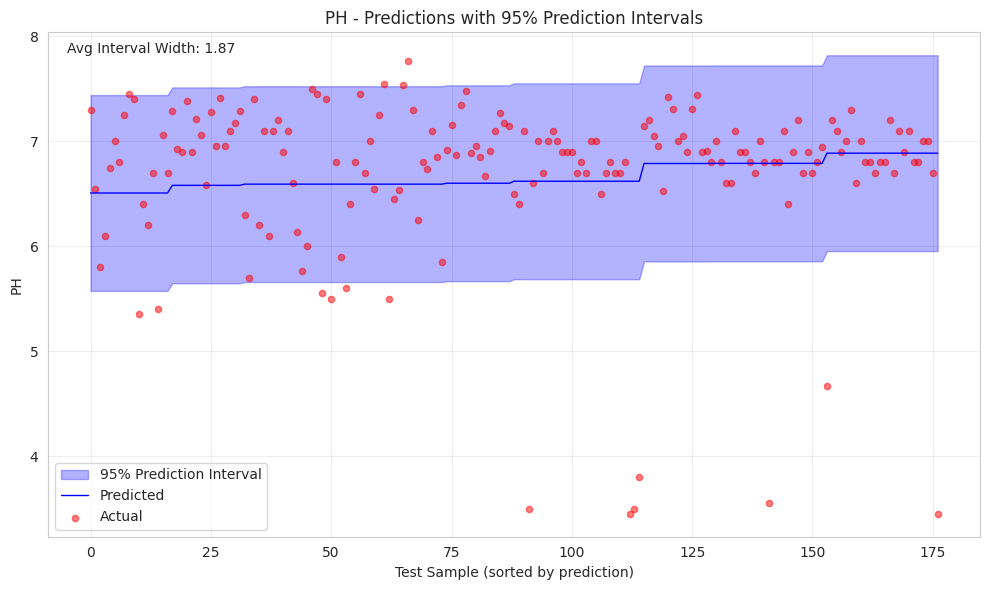

✅ Saved: Uncertainty_pH.png

✅ All uncertainty plots saved!


In [ ]:
print("=" * 60)
print("📊 VISUALIZING UNCERTAINTY")
print("=" * 60)

# For each parameter, create a plot
for target in target_columns:
    if target not in models:
        continue

    # Get test data
    y_test = test_df[target].copy()
    test_mask = ~y_test.isna()
    X_test_clean = X_test_scaled[test_mask]
    y_test_clean = y_test[test_mask]

    if len(X_test_clean) == 0:
        continue

    # Get predictions and intervals
    rf = models[target]
    y_pred = rf.predict(X_test_clean)

    # Calculate residuals and quantile
    residual_abs = np.abs(residuals[target])
    quantile_val = np.percentile(residual_abs, 95)

    # Create intervals
    lower = y_pred - quantile_val
    upper = y_pred + quantile_val

    # Create a DataFrame for plotting
    plot_df = pd.DataFrame({
        'Index': range(len(y_pred)),
        'Predicted': y_pred,
        'Lower': lower,
        'Upper': upper,
        'Actual': y_test_clean
    })

    # Sort by predicted value
    plot_df = plot_df.sort_values('Predicted').reset_index(drop=True)

    # Create plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot prediction intervals
    ax.fill_between(
        plot_df.index,
        plot_df['Lower'],
        plot_df['Upper'],
        alpha=0.3,
        color='blue',
        label='95% Prediction Interval'
    )

    # Plot predictions
    ax.plot(plot_df.index, plot_df['Predicted'], 'b-', label='Predicted', linewidth=1)

    # Plot actual values
    ax.scatter(plot_df.index, plot_df['Actual'], color='red', alpha=0.5, s=20, label='Actual')

    ax.set_title(f'{target.upper()} - Predictions with 95% Prediction Intervals')
    ax.set_xlabel('Test Sample (sorted by prediction)')
    ax.set_ylabel(target.upper())
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Add text showing interval width
    avg_width = np.mean(plot_df['Upper'] - plot_df['Lower'])
    ax.text(0.02, 0.98, f'Avg Interval Width: {avg_width:.2f}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top')

    plt.tight_layout()
    plt.savefig(f'Uncertainty_{target}.png', dpi=300)
    plt.show()
    print(f"✅ Saved: Uncertainty_{target}.png")

print("\n✅ All uncertainty plots saved!")

In [ ]:
print("=" * 60)
print("📄 GENERATING PHASE 10 REPORT")
print("=" * 60)

with open('Phase10_Uncertainty_Report.txt', 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("PHASE 10: UNCERTAINTY ESTIMATION REPORT\n")
    f.write("Groundwater Quality Forecasting Project\n")
    f.write(f"Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 80 + "\n\n")

    f.write("1. UNCERTAINTY METHOD\n")
    f.write("-" * 40 + "\n")
    f.write("Method: Conformal Prediction\n")
    f.write("Approach: Residual-based prediction intervals\n")
    f.write("Confidence Level: 95%\n\n")

    f.write("2. PREDICTION INTERVAL RESULTS\n")
    f.write("-" * 40 + "\n")
    f.write(uncertainty_df.to_string(index=False))
    f.write("\n\n")

    f.write("3. OUT-OF-DISTRIBUTION (OOD) DETECTION\n")
    f.write("-" * 40 + "\n")
    f.write(f"Total test points: {len(ood_df)}\n")
    f.write(f"OOD points detected: {ood_count} ({ood_count/len(ood_df)*100:.1f}%)\n")
    f.write("OOD detection based on z-score threshold = 2.0\n\n")

    f.write("4. KEY FINDINGS\n")
    f.write("-" * 40 + "\n")
    for _, row in uncertainty_df.iterrows():
        param = row['Parameter']
        coverage = row['Coverage_%']
        width = row['Avg_Width']

        if coverage >= 90:
            f.write(f"• {param}: Good coverage ({coverage:.1f}%), interval width: {width:.2f}\n")
        else:
            f.write(f"• {param}: Coverage ({coverage:.1f}%) is below 90%, intervals may be too narrow\n")

    f.write("\n5. RECOMMENDATION\n")
    f.write("-" * 40 + "\n")
    f.write("Use prediction intervals with all predictions.\n")
    f.write("Include OOD warnings for predictions outside training range.\n")
    f.write("Report coverage and interval widths in final product.\n\n")

    f.write("6. NEXT STEPS\n")
    f.write("-" * 40 + "\n")
    f.write("1. Phase 11: WQI Calculation\n")
    f.write("2. Phase 12: Research Paper\n")

print("\n✅ Phase10_Uncertainty_Report.txt saved!")

📄 GENERATING PHASE 10 REPORT

✅ Phase10_Uncertainty_Report.txt saved!
